# XCP-D mean time series: a beginner-friendly workflow

This notebook is the continuation of the XCP-D tutorial.

Our goal is to take one XCP-D mean time series file and turn it into something useful for network analysis.

We will do the following:

1. Load a real XCP-D mean time series file
2. Look at the shape of the data
3. Compute a parcel-by-parcel correlation matrix
4. Flatten the matrix to get pairwise correlations
5. Convert Pearson r values to Fisher z values
6. Collapse parcels into broader networks
7. Do a simple seed-based analysis

This is exactly the kind of workflow you will use when moving from preprocessing to connectivity analysis.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

# This points to the XCP-D derivatives we are using for this tutorial.
# You can replace this with a path on your own cluster or project folder.
XCP_DIR = Path('/projects/aabdulrasul/Tutorials/derivatives/xcp_d')

# Find the files that contain the mean time series for 456 parcels.
mean_ts_files = sorted(XCP_DIR.glob('**/*space-fsLR_seg-4S456Parcels_stat-mean_timeseries.tsv'))

print(f'Found {len(mean_ts_files)} mean time series files.')
for file in mean_ts_files[:5]:
    print(file)

if not mean_ts_files:
    raise FileNotFoundError('No XCP-D mean time series files were found in the derivatives folder.')

# Choose the first one as a working example.
mean_ts_path = mean_ts_files[0]
print(f'\nUsing: {mean_ts_path}')

Found 12 mean time series files.
/projects/aabdulrasul/Tutorials/derivatives/xcp_d/sub-CMH00000001/ses-01/func/sub-CMH00000001_ses-01_task-nback_run-01_space-fsLR_seg-4S456Parcels_stat-mean_timeseries.tsv
/projects/aabdulrasul/Tutorials/derivatives/xcp_d/sub-CMH00000001/ses-01/func/sub-CMH00000001_ses-01_task-nback_run-02_space-fsLR_seg-4S456Parcels_stat-mean_timeseries.tsv
/projects/aabdulrasul/Tutorials/derivatives/xcp_d/sub-CMH00000001/ses-01/func/sub-CMH00000001_ses-01_task-rest_run-01_space-fsLR_seg-4S456Parcels_stat-mean_timeseries.tsv
/projects/aabdulrasul/Tutorials/derivatives/xcp_d/sub-CMH00000001/ses-01/func/sub-CMH00000001_ses-01_task-rest_run-02_space-fsLR_seg-4S456Parcels_stat-mean_timeseries.tsv
/projects/aabdulrasul/Tutorials/derivatives/xcp_d/sub-CMH00000003/ses-01/func/sub-CMH00000003_ses-01_task-nback_run-01_space-fsLR_seg-4S456Parcels_stat-mean_timeseries.tsv

Using: /projects/aabdulrasul/Tutorials/derivatives/xcp_d/sub-CMH00000001/ses-01/func/sub-CMH00000001_ses-01_

## 1. Load the XCP-D mean time series

A mean time series file has rows as time points and columns as parcels.

For example, the file we are using here has:

- 387 rows = 387 time points
- 456 columns = 456 parcels

This means each parcel has its own time series across the scan.

In [2]:
# Read the TSV file.
# The file is tab-separated, so we use sep='\t'.
mean_ts = pd.read_csv(mean_ts_path, sep='\t')

print('Shape:', mean_ts.shape)
print('Rows (timepoints):', mean_ts.shape[0])
print('Columns (parcels):', mean_ts.shape[1])
print('\nFirst 5 rows:')
mean_ts.head()

Shape: (374, 456)
Rows (timepoints): 374
Columns (parcels): 456

First 5 rows:


,LH_Vis_1,LH_Vis_2,LH_Vis_3,LH_Vis_4,LH_Vis_5,LH_Vis_6,LH_Vis_7,LH_Vis_8,LH_Vis_9,LH_Vis_10,...,Cerebellar_Region1,Cerebellar_Region2,Cerebellar_Region3,Cerebellar_Region4,Cerebellar_Region5,Cerebellar_Region6,Cerebellar_Region7,Cerebellar_Region8,Cerebellar_Region9,Cerebellar_Region10
0,-0.026445,-0.969674,0.338937,0.166036,0.693288,0.550592,-0.320375,0.502025,0.811052,0.275324,...,0.032408,0.220237,-0.517619,-0.043772,-0.026401,-0.258438,-0.220541,-0.441644,-0.074658,-0.126686
1,-0.405611,-0.970439,-0.670139,-0.015314,0.426126,-0.831412,-0.389692,-0.106147,-0.778424,-0.103669,...,0.017645,0.001361,-0.510127,0.086075,-0.077146,-0.162652,-0.079037,-0.607038,-0.325594,0.066175
2,-0.671811,-0.855382,-1.325209,-0.104374,0.121565,-1.794730,-0.352805,-0.673197,-1.688249,-0.414994,...,-0.002280,-0.158736,-0.431897,0.134925,-0.111032,-0.030198,-0.006333,-0.729355,-0.575900,0.126144
3,-0.644202,-0.479695,-1.326882,0.058316,-0.032764,-2.065645,-0.165519,-0.881828,-1.633061,-0.549943,...,0.006030,-0.226937,-0.256996,0.098060,-0.139465,0.144608,-0.035851,-0.805553,-0.791548,0.027493
4,-0.318825,0.151370,-0.754598,0.424684,0.025464,-1.663929,0.141897,-0.663776,-0.804286,-0.483207,...,0.050216,-0.224339,-0.014213,0.010610,-0.160207,0.311208,-0.132535,-0.750564,-0.866436,-0.142034


In [ ]:
# Show the parcel names.
# These are the column names, which correspond to each parcel in the atlas.
mean_ts.columns[:10].tolist()

['LH_Vis_1',
 'LH_Vis_2',
 'LH_Vis_3',
 'LH_Vis_4',
 'LH_Vis_5',
 'LH_Vis_6',
 'LH_Vis_7',
 'LH_Vis_8',
 'LH_Vis_9',
 'LH_Vis_10']

## 2. Compute a parcel-by-parcel correlation matrix

Now we ask: how similar is parcel A to parcel B across time?

This gives us a connectivity matrix where each value is a Pearson correlation coefficient.

A value close to 1 means strong positive coupling.
A value close to 0 means weak or no linear relationship.
A value close to -1 means strong negative coupling.

In [4]:
# Compute the parcel-by-parcel correlation matrix.
# The result is a 456 x 456 matrix.
correlation_matrix = mean_ts.corr(method='pearson')

print('Correlation matrix shape:', correlation_matrix.shape)


Correlation matrix shape: (456, 456)


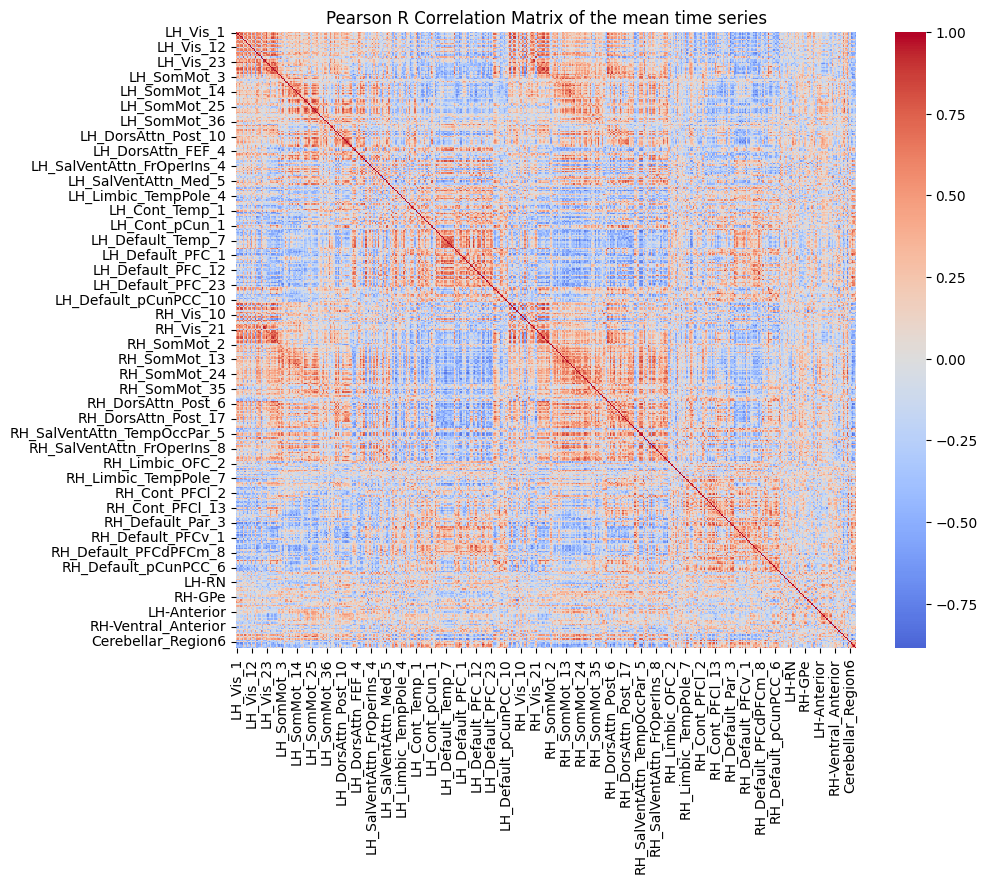

In [5]:
## We can also plot the correlation matrix as a heatmap. 

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0)
plt.title('Pearson R Correlation Matrix of the mean time series')
plt.show()

## 3. Fisher-transform the Correlation Matrix

In [6]:
# Fisher transformation of the correlation matrix.
# This is often done to stabilize the variance of correlation coefficients. Also makes interpretation a lot easier. 
# zero out the self correlations (diagonal) to avoid infinities in the Fisher transformation.
# Z transformation is very common in the field, but as always, consult with literature, supervisor and as a sanity check, run a correlation between both matrices to see if they are highly correlated.
z_matrix = np.arctanh(correlation_matrix)

print('Fisher z-transformed matrix shape:', z_matrix.shape)



Fisher z-transformed matrix shape: (456, 456)


/mnt/tigrlab/projects/aabdulrasul/TAY/PhD_1/MRI/gt_env/lib/python3.12/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: divide by zero encountered in arctanh
  result = func(self.values, **kwargs)


/mnt/tigrlab/projects/aabdulrasul/TAY/PhD_1/MRI/gt_env/lib/python3.12/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)


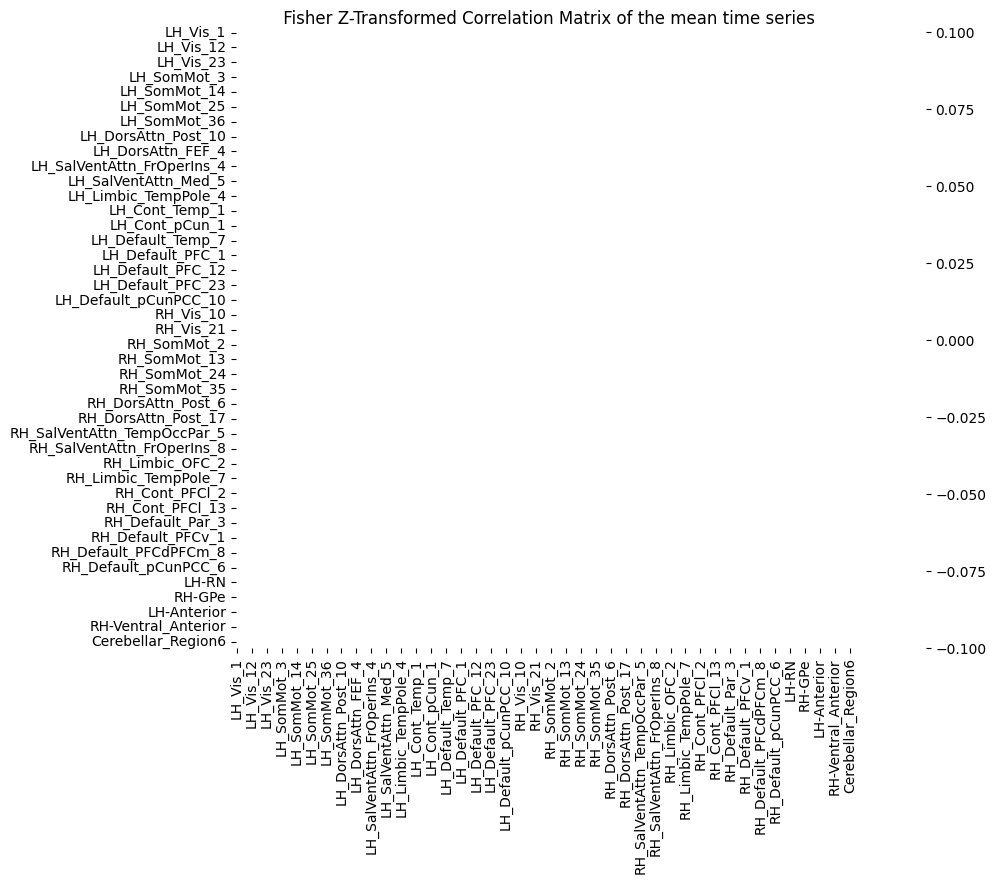

In [ ]:
## plot the correlation matrix as a heatmap. 

plt.figure(figsize=(10, 8))
sns.heatmap(z_matrix, cmap='coolwarm', center=0)
plt.title(' Fisher Z-Transformed Correlation Matrix of the mean time series')
plt.show()

## 4. Flatten the matrix

A full matrix is useful, but for many analyses we want a long table of pairwise correlations.

We can:

- keep only the upper triangle
- drop the diagonal (self-correlation)
- convert each r value to a Fisher z score using $z = \\text{atanh}(r)$

This step helps make the distribution of correlations more normal for downstream statistics.

In [ ]:
# Make a matrix of True/False values so we can keep only the upper triangle.
# The diagonal is excluded by setting k=1.
mask = np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)

upper_triangle = correlation_matrix.where(mask)

# Convert the matrix to a long dataframe.
flat_corr = upper_triangle.stack().reset_index()
flat_corr.columns = ['parcel_1', 'parcel_2', 'r']

# Remove missing values and keep only real pairwise comparisons.
flat_corr = flat_corr.dropna().reset_index(drop=True)

# Remove self-pairs. This should already be removed by the upper triangle mask,
# but we keep this safety step anyway.
flat_corr = flat_corr[flat_corr['parcel_1'] != flat_corr['parcel_2']].reset_index(drop=True)

# Fisher z-transform for each Pearson r.
flat_corr['z'] = np.arctanh(flat_corr['r'])

print('Number of pairwise correlations:', len(flat_corr))
flat_corr.head()

## 4. Network-level summary

The mean time series file contains parcels, not networks.

To answer questions like:

- How connected is the visual network to the default network?
- Are somatomotor parcels more connected with control parcels than with visual parcels?

we need to collapse parcels into larger groups.

A simple way to do this is to map parcel names to network labels using their names.
For example:

- LH_Vis_1 -> Visual
- RH_SomMot_2 -> SomMot
- LH_Default_7 -> Default

This is a beginner-friendly approximation, and in real analyses you should use the atlas/network labels that match your study design and documentation.

In [ ]:
# Define a small mapping from parcel-name prefixes to network names.
# This is intentionally simple and beginner-friendly.
# We only need a rough grouping to demonstrate the workflow.
network_map = {
    'Vis': 'Visual',
    'SomMot': 'SomMot',
    'DorsAttn': 'DorsAttn',
    'SalVentAttn': 'SalVentAttn',
    'Limbic': 'Limbic',
    'Cont': 'Cont',
    'Default': 'Default',
    'Cerebellar': 'Cerebellar',
    'Thalamus': 'Thalamus',
}


def parcel_to_network(parcel_name):
    """Convert a parcel label like 'LH_Vis_1' to a network label."""
    parts = parcel_name.split('_')
    if len(parts) >= 2:
        prefix = parts[1]
        return network_map.get(prefix, 'Other')
    return 'Other'


# Build the network groups.
network_groups = {}
for parcel in correlation_matrix.columns:
    network = parcel_to_network(parcel)
    network_groups.setdefault(network, []).append(parcel)

# Print the groups we found.
for network_name, parcels in network_groups.items():
    print(f'{network_name}: {len(parcels)} parcels')

In [ ]:
# Compute a network-by-network connectivity matrix.
# Each entry is the average correlation between parcels in one network and parcels in another network.
network_names = sorted(network_groups.keys())
network_matrix = pd.DataFrame(np.nan, index=network_names, columns=network_names)

for net_a in network_names:
    for net_b in network_names:
        parcels_a = network_groups[net_a]
        parcels_b = network_groups[net_b]
        values = correlation_matrix.loc[parcels_a, parcels_b]
        network_matrix.loc[net_a, net_b] = values.to_numpy().mean()

network_matrix.round(3)

## 5. Ask a question: how connected is network A to network B?

This is the kind of question you can answer once you have a network matrix.

For example:

- How connected are the visual and default networks?
- Is the somatomotor network more connected to dorsal attention than to limbic regions?
- Which network pairs show the strongest average coupling?

The network matrix is a useful summary of the full parcel matrix.

In [ ]:
# Example: print the strongest connections between network pairs.
# We ignore the diagonal because a network is not compared to itself.
network_matrix = network_matrix.astype(float)
network_pairs = network_matrix.where(~np.eye(network_matrix.shape[0], dtype=bool)).stack().reset_index()
network_pairs.columns = ['network_1', 'network_2', 'mean_corr']
network_pairs = network_pairs.dropna().reset_index(drop=True)
network_pairs = network_pairs.sort_values('mean_corr', ascending=False)

network_pairs.head(10)

## 6. Seed-based analysis: pick one parcel and compare it to all others

A seed-based analysis asks:

- Which parcels are most strongly correlated with this seed parcel?

This is a simple and popular way to read a connectivity matrix.

Here we choose a visual parcel as the seed.

In [ ]:
# Choose a parcel to use as the seed.
# We pick the first parcel in the visual network as an example.
seed_name = 'LH_Vis_1'

if seed_name not in correlation_matrix.columns:
    seed_name = correlation_matrix.columns[0]
    print(f'Seed not found; using the first parcel instead: {seed_name}')

seed_corr = correlation_matrix[seed_name].drop(seed_name).sort_values(ascending=False)
seed_corr.head(10)

## 7. Save the outputs

Now that we have created the connectivity outputs, we can save them for later use.

This is helpful when you want to:

- inspect the matrix in another script
- visualize it in a separate notebook
- compare subjects or groups later

In [ ]:
# Save the outputs to a local folder so they can be reused.
out_dir = Path('/projects/aabdulrasul/Tutorials/fMRI_basics/outputs/xcpd_example')
out_dir.mkdir(parents=True, exist_ok=True)

correlation_matrix.to_csv(out_dir / 'parcel_correlation_matrix.tsv', sep='\t')
flat_corr.to_csv(out_dir / 'pairwise_correlations.tsv', sep='\t', index=False)
network_matrix.to_csv(out_dir / 'network_correlation_matrix.tsv', sep='\t')
seed_corr.to_csv(out_dir / 'seed_based_correlations.tsv', sep='\t', header=['correlation'])

print(f'Files written to {out_dir}')

## 8. What this gives you in practice

From one XCP-D mean time series file, you can now do the basic steps of a functional connectivity analysis:

- parcel-to-parcel correlation matrix
- flattened pairwise correlations
- Fisher z-transformed values
- network-level summaries
- seed-based connectivity

This is a good beginner workflow because it keeps the logic clear:

1. Start with the time series.
2. Compute similarity between parcels.
3. Summarize the results at the network level.
4. Pick a seed region and describe its connectivity.

In later tutorials, you can build on this by comparing groups, adding confounds, or testing whether a network relationship differs across participants.

In [9]:
# Optional final check: confirm the key outputs exist.
for file in sorted(out_dir.glob('*')):
    print(file.name)

NameError: name 'out_dir' is not defined